# 🧬 Chromosome Classification — MobileNetV2


Loading Trained model

In [ ]:
# Load Cell — run this instead of training cells in future sessions
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import numpy as np
import json, os
import matplotlib.pyplot as plt

SAVE_DIR = '/content/drive/MyDrive/chromosome_models'

# Config — must redeclare since training cells are skipped
IMG_SIZE       = 128
NUM_CLASSES    = 24
CLASS_NAMES    = [str(i) for i in range(1, 23)] + ['X', 'Y']
CONF_THRESHOLD = 0.70
BATCH_SIZE     = 64
SEED           = 42

# ── Load model ────────────────────────────────────────────────────────────────
print('Loading model...')
model = tf.keras.models.load_model(
    f'{SAVE_DIR}/mobilenetv2_bioimlab_final.keras')
print('✅ Model loaded')
print(f'   Input shape  : {model.input_shape}')
print(f'   Output shape : {model.output_shape}')

# ── Load test labels and probabilities ───────────────────────────────────────
lbl_test   = np.load(f'{SAVE_DIR}/lbl_test.npy')
probs_test = np.load(f'{SAVE_DIR}/mobilenetv2_test_probs.npy')
preds_test = np.argmax(probs_test, axis=1)
print(f'✅ Test labels loaded     : {lbl_test.shape}')
print(f'✅ Test probs loaded      : {probs_test.shape}')

# ── Load training history ─────────────────────────────────────────────────────
with open(f'{SAVE_DIR}/mobilenetv2_history.json') as f:
    hist = json.load(f)

acc      = hist['phase1_accuracy']     + hist['phase2_accuracy']
val_acc  = hist['phase1_val_accuracy'] + hist['phase2_val_accuracy']
loss     = hist['phase1_loss']         + hist['phase2_loss']
val_loss = hist['phase1_val_loss']     + hist['phase2_val_loss']
p1_end   = len(hist['phase1_accuracy'])
ep       = range(1, len(acc) + 1)

# ── Plot training curves ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ep, [a * 100 for a in acc],     'b-', linewidth=2, label='Train')
ax1.plot(ep, [a * 100 for a in val_acc], 'r-', linewidth=2, label='Val')
ax1.axvline(p1_end, color='gray', linestyle='--', alpha=0.7, label='Unfreeze')
ax1.axhline(90, color='green', linestyle=':', alpha=0.5, label='90% target')
ax1.set_title(f'Accuracy | Best Val = {max(val_acc)*100:.2f}%', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy (%)')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep, loss,     'b-', linewidth=2, label='Train')
ax2.plot(ep, val_loss, 'r-', linewidth=2, label='Val')
ax2.axvline(p1_end, color='gray', linestyle='--', alpha=0.7, label='Unfreeze')
ax2.set_title('Loss', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('MobileNetV2 — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Quick accuracy check ──────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score
acc_score = accuracy_score(lbl_test, preds_test) * 100
f1        = f1_score(lbl_test, preds_test, average='macro', zero_division=0)

print(f'\n{"="*45}')
print(f'  MODEL READY')
print(f'{"="*45}')
print(f'  Best val accuracy : {max(val_acc)*100:.2f}%')
print(f'  Test accuracy     : {acc_score:.2f}%')
print(f'  Macro F1          : {f1:.4f}')
print(f'  Test samples      : {len(lbl_test)}')
print(f'{"="*45}')
print('\n✅ Ready — skip to Cell 9 or Cell 10 directly')

cell 0A

In [1]:
# Cell 0A — Download BOTH datasets into Colab
import os
from google.colab import files

print("📁 Upload your kaggle.json file...")
uploaded = files.upload()
uploaded_name = list(uploaded.keys())[0]

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded[uploaded_name])
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ kaggle.json placed")

!pip install -q kaggle

# ── Download BioImLAB dataset (training data) ─────────────────────────────────
if os.path.exists('/content/bioimlab/Class_1'):
    print("✅ BioImLAB already exists — skipping")
else:
    print("📥 Downloading BioImLAB dataset (~200MB)...")
    !kaggle datasets download \
        -d arifmpthesis/bioimlab-chromosome-data-set-for-classification \
        --path /content/bioimlab \
        --unzip -q
    print("✅ BioImLAB downloaded")

# ── Download old Kaggle dataset (inference data) ──────────────────────────────
if os.path.exists('/content/chromo_data/Data/24_chromosomes_object/JEPG'):
    print("✅ Old dataset already exists — skipping")
else:
    print("📥 Downloading old chromosome dataset (~500MB)...")
    !kaggle datasets download \
        -d aliabedimadiseh/chromosome-image-dataset-karyotype \
        --path /content/chromo_data \
        --unzip -q
    print("✅ Old dataset downloaded")

# ── Verify both ───────────────────────────────────────────────────────────────
print("\n=== BioImLAB structure ===")
for f in sorted(os.listdir('/content/bioimlab'))[:5]:
    path = os.path.join('/content/bioimlab', f)
    if os.path.isdir(path):
        print(f"  {f}/  ({len(os.listdir(path))} images)")

print("\n=== Old dataset structure ===")
base = '/content/chromo_data'
for root, dirs, files_list in os.walk(base):
    level = root.replace(base,'').count(os.sep)
    if level > 3: continue
    indent = '  '*level
    print(f'{indent}{os.path.basename(root)}/')

📁 Upload your kaggle.json file...


Saving kaggle.json to kaggle (1).json
✅ kaggle.json placed
✅ BioImLAB already exists — skipping
✅ Old dataset already exists — skipping

=== BioImLAB structure ===
  Class_1/  (238 images)
  Class_10/  (238 images)
  Class_11/  (238 images)
  Class_12/  (238 images)
  Class_13/  (238 images)

=== Old dataset structure ===
chromo_data/
  Data/
    24_chromosomes_object/
      JEPG/
      annotations/
    weight/
    single_chromosomes_object/
      JEPG/
      anntations/


Cell 0B

In [2]:
# ── NEW CELL 0B: Verify GPU ──────────────────────────────────────────────────
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print(f'✅ GPU active: {gpus[0].name}')
    print(f'   Make sure you selected GPU in Runtime → Change runtime type')
else:
    print('⚠️  NO GPU DETECTED')
    print('   Go to: Runtime → Change runtime type → Hardware accelerator → T4 GPU')
    print('   Then run this cell again')

tf.keras.mixed_precision.set_global_policy('float32')
print('✅ Precision: float32')

✅ GPU active: /physical_device:GPU:0
   Make sure you selected GPU in Runtime → Change runtime type
✅ Precision: float32


## Cell 1 — Setup + Imports

In [3]:
# Cell 1 — Imports + GPU setup
import tensorflow as tf, os, re, warnings, gc
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score,
                              confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import xml.etree.ElementTree as ET
import cv2
warnings.filterwarnings('ignore')

SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    [tf.config.experimental.set_memory_growth(g, True) for g in gpus]
    print(f'✅ GPU: {gpus[0].name}')
else:
    print('💻 CPU mode')
tf.keras.mixed_precision.set_global_policy('float32')
print('✅ Imports done')

✅ GPU: /physical_device:GPU:0
✅ Imports done


## Cell 2 — Config + Load labels + Split

In [4]:
# Cell 2 — Config
# ── TRAINING dataset (BioImLAB) ───────────────────────────────────────────────
BIOIMLAB_DIR = '/content/bioimlab'

# ── INFERENCE dataset (old Kaggle dataset) ────────────────────────────────────
OLD_DATA_ROOT = '/content/chromo_data/Data'
OLD_IMG_DIR   = os.path.join(OLD_DATA_ROOT, '24_chromosomes_object', 'JEPG')
OLD_ANN_DIR   = os.path.join(OLD_DATA_ROOT, '24_chromosomes_object', 'annotations')
NORM_CSV      = os.path.join(OLD_DATA_ROOT, 'normal.csv')
NABN_CSV      = os.path.join(OLD_DATA_ROOT, 'number_abnormalities.csv')
SABN_CSV      = os.path.join(OLD_DATA_ROOT, 'structural_abnormalities.csv')

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE       = 128      # chromosomes are small — 96 is enough
BATCH_SIZE     = 64
NUM_CLASSES    = 24
EPOCHS_P1      = 20
EPOCHS_P2      = 80
LR_P1          = 1e-3
LR_P2          = 1e-4
DROPOUT        = 0.35
L2_REG         = 2e-4
LABEL_SMOOTH   = 0.10
REPEAT_FACTOR  = 5
PATIENCE_P1    = 8
PATIENCE_P2    = 20
CONF_THRESHOLD = 0.65   # below this = flag as possibly abnormal
CLASS_NAMES    = [str(i) for i in range(1, 23)] + ['X', 'Y']
IMG_EXTS       = ('.jpg', '.jpeg', '.png', '.bmp')
AUTOTUNE       = tf.data.AUTOTUNE
OUTPUT_DIR     = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('✅ Config loaded')

✅ Config loaded


## Cell 3 — tf.data Pipeline

✅ BioImLAB loaded : 5474 images
   Classes         : 24/24
   Min per class   : 45
   Max per class   : 238

Per-class counts:
  Chr  1:  238  ███████████████████████
  Chr  2:  238  ███████████████████████
  Chr  3:  238  ███████████████████████
  Chr  4:  238  ███████████████████████
  Chr  5:  238  ███████████████████████
  Chr  6:  238  ███████████████████████
  Chr  7:  238  ███████████████████████
  Chr  8:  238  ███████████████████████
  Chr  9:  238  ███████████████████████
  Chr 10:  238  ███████████████████████
  Chr 11:  238  ███████████████████████
  Chr 12:  238  ███████████████████████
  Chr 13:  238  ███████████████████████
  Chr 14:  238  ███████████████████████
  Chr 15:  238  ███████████████████████
  Chr 16:  238  ███████████████████████
  Chr 17:  238  ███████████████████████
  Chr 18:  238  ███████████████████████
  Chr 19:  238  ███████████████████████
  Chr 20:  238  ███████████████████████
  Chr 21:  238  ███████████████████████
  Chr 22:  238  █████████████████

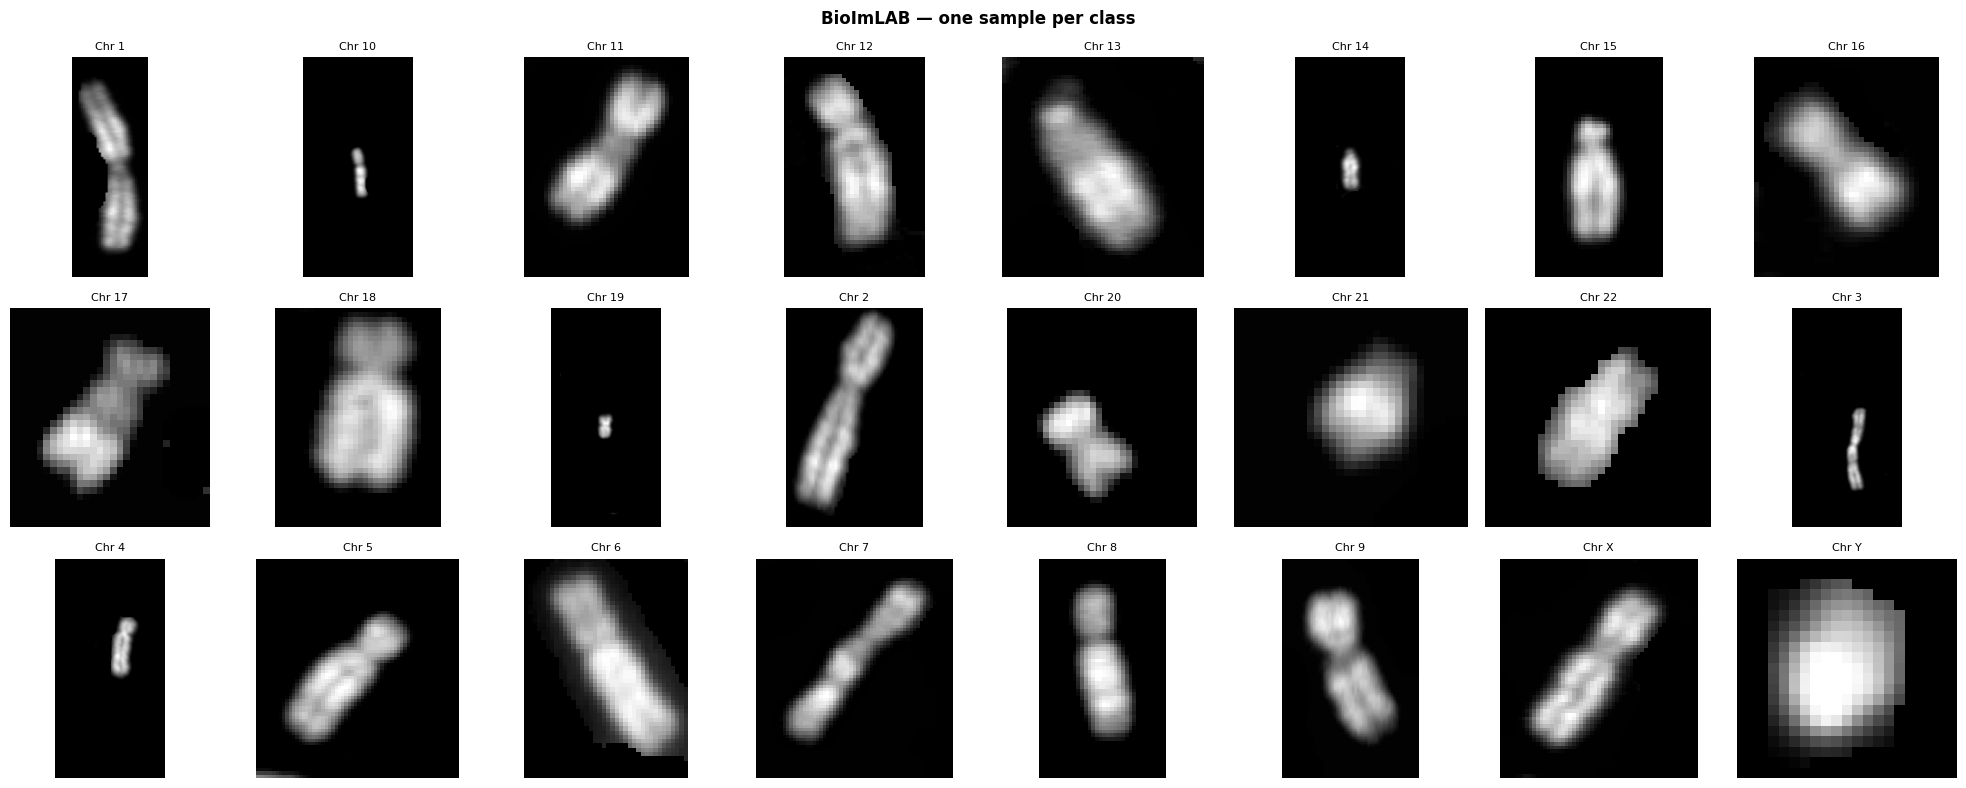


✅ Split done
   Train : 4379  (182 per class avg)
   Val   : 1095   (45 per class avg)
   Steps/epoch      : 342
   Val accuracy res : 0.091% per image


In [5]:
# Cell 3 — Load BioImLAB
def load_bioimlab(root_dir):
    records = []
    missing_classes = []
    for folder in sorted(os.listdir(root_dir)):
        fpath = os.path.join(root_dir, folder)
        if not os.path.isdir(fpath):
            continue
        if not folder.startswith('Class_'):
            continue

        suffix = folder.replace('Class_', '')
        if suffix == 'X':
            cls_idx = 22
        elif suffix == 'Y':
            cls_idx = 23
        else:
            try:
                cls_idx = int(suffix) - 1
            except:
                continue

        if cls_idx < 0 or cls_idx >= NUM_CLASSES:
            continue

        # Accept bmp + jpg + png
        imgs = [f for f in os.listdir(fpath)
                if f.lower().endswith(('.bmp','.jpg','.jpeg','.png'))]
        if len(imgs) == 0:
            missing_classes.append(cls_idx)
            continue
        for fname in imgs:
            records.append((os.path.join(fpath, fname), cls_idx))

    dist = Counter(r[1] for r in records)
    print(f'✅ BioImLAB loaded : {len(records)} images')
    print(f'   Classes         : {len(dist)}/24')
    print(f'   Min per class   : {min(dist.values())}')
    print(f'   Max per class   : {max(dist.values())}')
    if missing_classes:
        print(f'   Missing         : {missing_classes}')

    print('\nPer-class counts:')
    for i in range(NUM_CLASSES):
        count = dist.get(i, 0)
        bar   = '█' * (count // 10)
        print(f'  Chr {CLASS_NAMES[i]:>2}: {count:4d}  {bar}')
    return records

all_records = load_bioimlab(BIOIMLAB_DIR)

# Visualize sample images
fig, axes = plt.subplots(3, 8, figsize=(20, 8))
shown = {}
for fp, lbl in all_records:
    if lbl not in shown and len(shown) < 24:
        img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            r, c = len(shown) // 8, len(shown) % 8
            axes[r][c].imshow(img, cmap='gray')
            axes[r][c].set_title(f'Chr {CLASS_NAMES[lbl]}', fontsize=8)
            axes[r][c].axis('off')
            shown[lbl] = True
for ax in axes.flatten():
    if not ax.has_data():
        ax.axis('off')
plt.suptitle('BioImLAB — one sample per class', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Split 80/20
fps    = [r[0] for r in all_records]
labels = [r[1] for r in all_records]

fps_train, fps_val, lbl_train, lbl_val = train_test_split(
    fps, labels, test_size=0.20,
    random_state=SEED, stratify=labels)

train_records = list(zip(fps_train, lbl_train))
val_records   = list(zip(fps_val,   lbl_val))
test_records  = val_records
lbl_test      = lbl_val

cls_wts = compute_class_weight('balanced',
                                classes=np.arange(NUM_CLASSES),
                                y=lbl_train)
class_weight_dict = dict(enumerate(cls_wts))
steps = (len(train_records) * REPEAT_FACTOR) // BATCH_SIZE

print(f'\n✅ Split done')
print(f'   Train : {len(train_records)}  ({len(train_records)//NUM_CLASSES} per class avg)')
print(f'   Val   : {len(val_records)}   ({len(val_records)//NUM_CLASSES} per class avg)')
print(f'   Steps/epoch      : {steps}')
print(f'   Val accuracy res : {100/len(val_records):.3f}% per image')

Balancing cell

In [6]:
# NEW CELL — Balance classes (add between Cell 3 and Cell 4)
from collections import defaultdict, Counter

MAX_PER_CLASS = 200

balanced = []
count    = defaultdict(int)

for fp, lbl in all_records:
    if count[lbl] < MAX_PER_CLASS:
        balanced.append((fp, lbl))
        count[lbl] += 1

all_records = balanced   # replace with balanced version

dist = Counter(r[1] for r in all_records)
print(f'✅ Balanced dataset: {len(all_records)} total images')
print(f'   Classes: {len(dist)}/24')
print(f'   Min per class: {min(dist.values())}')
print(f'   Max per class: {max(dist.values())}')
print('\nPer-class counts after balancing:')
for i in range(NUM_CLASSES):
    count_i = dist.get(i, 0)
    bar     = '█' * (count_i // 10)
    print(f'  Chr {CLASS_NAMES[i]:>2}: {count_i:3d}  {bar}')

✅ Balanced dataset: 4638 total images
   Classes: 24/24
   Min per class: 45
   Max per class: 200

Per-class counts after balancing:
  Chr  1: 200  ████████████████████
  Chr  2: 200  ████████████████████
  Chr  3: 200  ████████████████████
  Chr  4: 200  ████████████████████
  Chr  5: 200  ████████████████████
  Chr  6: 200  ████████████████████
  Chr  7: 200  ████████████████████
  Chr  8: 200  ████████████████████
  Chr  9: 200  ████████████████████
  Chr 10: 200  ████████████████████
  Chr 11: 200  ████████████████████
  Chr 12: 200  ████████████████████
  Chr 13: 200  ████████████████████
  Chr 14: 200  ████████████████████
  Chr 15: 200  ████████████████████
  Chr 16: 200  ████████████████████
  Chr 17: 200  ████████████████████
  Chr 18: 200  ████████████████████
  Chr 19: 200  ████████████████████
  Chr 20: 200  ████████████████████
  Chr 21: 200  ████████████████████
  Chr 22: 200  ████████████████████
  Chr  X: 193  ███████████████████
  Chr  Y:  45  ████


## Cell 4 — Model

In [8]:
# Cell 4 — Pipeline (definitive version, run after kernel restart)
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_tf(filepath, label):
    raw = tf.io.read_file(filepath)
    # BMP must be decoded as 3 channels — cannot use channels=1 for BMP
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    # Convert color to grayscale then back to 3 channels
    # This ensures consistent single-channel content in 3-channel format
    img = tf.image.rgb_to_grayscale(img)           # (H,W,3) → (H,W,1)
    img = tf.concat([img, img, img], axis=-1)      # (H,W,1) → (H,W,3)
    img = (img * 2.0) - 1.0                        # [0,1] → [-1,1]
    return img, tf.one_hot(label, NUM_CLASSES)

def augment_fn(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    k     = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    return tf.clip_by_value(image, -1.0, 1.0), label

train_ds = (
    tf.data.Dataset.from_tensor_slices(
        ([r[0] for r in train_records], [r[1] for r in train_records]))
    .shuffle(len(train_records), seed=SEED, reshuffle_each_iteration=True)
    .map(preprocess_tf, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .map(augment_fn, num_parallel_calls=AUTOTUNE)
    .repeat()
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices(
        ([r[0] for r in val_records], [r[1] for r in val_records]))
    .map(preprocess_tf, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices(
        ([r[0] for r in test_records], [r[1] for r in test_records]))
    .map(preprocess_tf, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

steps = (len(train_records) * REPEAT_FACTOR) // BATCH_SIZE

# Verify — both must show (64, 128, 128, 3)
for imgs, _ in train_ds.take(1):
    print(f'Train shape : {imgs.shape}  ← must be (64, 128, 128, 3)')
    print(f'Pixel range : [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]')
    break
for imgs, _ in val_ds.take(1):
    print(f'Val shape   : {imgs.shape}  ← must be (64, 128, 128, 3)')
    break
print(f'Steps/epoch : {steps}')

Train shape : (64, 128, 128, 3)  ← must be (64, 128, 128, 3)
Pixel range : [-1.00, 0.90]
Val shape   : (64, 128, 128, 3)  ← must be (64, 128, 128, 3)
Steps/epoch : 342


In [9]:
for imgs, _ in train_ds.take(1):
    print(f'Train shape : {imgs.shape}')
    print(f'Pixel range : [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]')
    break

Train shape : (64, 128, 128, 3)
Pixel range : [-1.00, 0.94]


## Cell 5 — Training (Phase 1 +  Phase 2)

In [10]:
# Cell 5 — MobileNetV2 model for single chromosome classification
from tensorflow.keras.applications import MobileNetV2
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers

def build_model():
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name='input')

    # Expand 1 channel → 3 channels for MobileNetV2
    x = layers.Conv2D(3, 1, padding='same', use_bias=False,
                      kernel_initializer='he_uniform',
                      name='channel_expand')(inp)
    x = layers.BatchNormalization(name='channel_bn')(x)

    base = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False   # Phase 1: freeze backbone

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Dropout(DROPOUT, name='drop1')(x)
    x = layers.Dense(512, activation='relu',
                     kernel_initializer='he_uniform',
                     kernel_regularizer=regularizers.l2(L2_REG),
                     name='dense512')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Dropout(DROPOUT, name='drop2')(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax',
                       kernel_initializer='glorot_uniform',
                       dtype='float32', name='output')(x)

    return Model(inp, out, name='MobileNetV2_Chromo'), base

model, backbone = build_model()
total    = sum(v.numpy().size for v in model.weights) / 1e6
trainable = sum(v.numpy().size for v in model.trainable_weights) / 1e6
print(f'✅ Model ready')
print(f'   Total params      : {total:.1f}M')
print(f'   Trainable Phase 1 : {trainable:.3f}M  (head only)')

✅ Model ready
   Total params      : 2.9M
   Trainable Phase 1 : 0.672M  (head only)


## Cell 6 — Evaluate + Save

cell 6 & 7

In [11]:
# Cell 6+7 — Complete training with all optimizations
from tensorflow.keras.applications import MobileNetV2
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
import time

# ── Model definition ──────────────────────────────────────────────────────────
def build_mobilenet():
    inp  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input')
    base = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        alpha=1.0
    )
    base.trainable = False

    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    # He uniform — correct for ReLU, prevents vanishing gradient
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Dropout(DROPOUT, name='drop1')(x)
    x = layers.Dense(
        512, activation='relu',
        kernel_initializer='he_uniform',
        kernel_regularizer=regularizers.l2(L2_REG),
        name='dense_512'
    )(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Dropout(DROPOUT, name='drop2')(x)
    x = layers.Dense(
        256, activation='relu',
        kernel_initializer='he_uniform',
        kernel_regularizer=regularizers.l2(L2_REG),
        name='dense_256'
    )(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Dropout(0.25, name='drop3')(x)
    out = layers.Dense(
        NUM_CLASSES, activation='softmax',
        kernel_initializer='glorot_uniform',
        dtype='float32', name='output'
    )(x)

    model = Model(inp, out, name='MobileNetV2_Final')
    return model, base

model, base = build_mobilenet()

total     = sum(v.numpy().size for v in model.weights)/1e6
trainable = sum(v.numpy().size for v in model.trainable_weights)/1e6
print(f'✅ Model built: {total:.1f}M total | {trainable:.2f}M trainable (Phase 1)')

# ── Loss function ─────────────────────────────────────────────────────────────
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH)
ckpt    = f'{OUTPUT_DIR}/mobilenetv2_bioimlab_best.keras'

# ════════════════════════════════════════════════════════════════════════
# PHASE 1: Frozen backbone — train head only
# Purpose: initialize head weights before backbone unfreezes
# LR = 1e-3 (high LR safe since backbone is frozen)
# ════════════════════════════════════════════════════════════════════════
print('\n=== PHASE 1: Frozen backbone | LR=1e-3 | Epochs=20 ===')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_P1),
    loss=loss_fn,
    metrics=['accuracy']
)

cb_p1 = [
    keras.callbacks.ModelCheckpoint(
        ckpt, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1),
    # Early stopping: stop if val_accuracy doesn't improve for 8 epochs
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1),
    # Halve LR if val_loss stagnates for 4 epochs
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-7, verbose=1),
]

t0 = time.time()
h1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    steps_per_epoch=steps,
    callbacks=cb_p1,
    class_weight=class_weight_dict,
    verbose=1
)
p1_best = max(h1.history['val_accuracy'])*100
print(f'\n✅ Phase 1 done | Best val_acc: {p1_best:.2f}% | Time: {(time.time()-t0)/60:.1f} min')

# ════════════════════════════════════════════════════════════════════════
# PHASE 2: Unfreeze last 60 layers — full fine-tuning
# LR = 1e-4 (10x lower than Phase 1 to preserve ImageNet features)
# Gradient clipping: prevents exploding gradients in deep layers
# ════════════════════════════════════════════════════════════════════════
print('\n=== PHASE 2: Unfreeze last 60 layers | LR=1e-4 | Epochs=100 ===')

# Unfreeze last 60 layers of MobileNetV2 backbone
base.trainable = True
for layer in base.layers[:-60]:
    layer.trainable = False

trainable_p2 = sum(v.numpy().size for v in model.trainable_weights)/1e6
print(f'Trainable params Phase 2: {trainable_p2:.1f}M')

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LR_P2,
        clipnorm=1.0     # gradient clipping — prevents exploding gradients
    ),
    loss=loss_fn,
    metrics=['accuracy']
)

cb_p2 = [
    keras.callbacks.ModelCheckpoint(
        ckpt, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1),
    # Early stopping with patience=20 — gives model enough time to improve
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=20,
        restore_best_weights=True, verbose=1),
    # ReduceLROnPlateau: halve LR when stuck
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-8, verbose=1),
]

t1 = time.time()
h2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,          # let early stopping decide when to stop
    steps_per_epoch=steps,
    callbacks=cb_p2,
    class_weight=class_weight_dict,
    verbose=1
)
p2_best = max(h2.history['val_accuracy'])*100
print(f'\n✅ Phase 2 done | Best val_acc: {p2_best:.2f}% | Time: {(time.time()-t1)/60:.1f} min')
model.load_weights(ckpt)
print('✅ Best weights restored')

✅ Model built: 3.1M total | 0.80M trainable (Phase 1)

=== PHASE 1: Frozen backbone | LR=1e-3 | Epochs=20 ===
Epoch 1/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.1781 - loss: 3.3746
Epoch 1: val_accuracy improved from None to 0.36164, saving model to /kaggle/working/mobilenetv2_bioimlab_best.keras

Epoch 1: finished saving model to /kaggle/working/mobilenetv2_bioimlab_best.keras
342/342 ━━━━━━━━━━━━━━━━━━━━ 83s 182ms/step - accuracy: 0.2370 - loss: 3.0018 - val_accuracy: 0.3616 - val_loss: 2.5477 - learning_rate: 0.0010
Epoch 2/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.3289 - loss: 2.5921
Epoch 2: val_accuracy improved from 0.36164 to 0.40000, saving model to /kaggle/working/mobilenetv2_bioimlab_best.keras

Epoch 2: finished saving model to /kaggle/working/mobilenetv2_bioimlab_best.keras
342/342 ━━━━━━━━━━━━━━━━━━━━ 29s 85ms/step - accuracy: 0.3418 - loss: 2.5514 - val_accuracy: 0.4000 - val_loss: 2.4176 - learning_rate: 0.0010
Epoch 3/20
342/342 ━━━━━━

Model saving

In [23]:
# Save Cell — Run immediately after training completes
import os, json
import numpy as np

SAVE_DIR   = '/content/drive/MyDrive/chromosome_models'
OUTPUT_DIR = '/content'   # checkpoint was saved here during training
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Save full model ───────────────────────────────────────────────────────────
print('Saving model...')
model.save(f'{SAVE_DIR}/mobilenetv2_bioimlab_final.keras')
print(f'✅ Full model saved')

# ── Save weights separately as backup ────────────────────────────────────────
model.save_weights(f'{SAVE_DIR}/mobilenetv2_bioimlab_weights.weights.h5')
print(f'✅ Weights saved')

# ── Save training history ─────────────────────────────────────────────────────
history_data = {
    'phase1_accuracy'    : h1.history['accuracy'],
    'phase1_val_accuracy': h1.history['val_accuracy'],
    'phase1_loss'        : h1.history['loss'],
    'phase1_val_loss'    : h1.history['val_loss'],
    'phase2_accuracy'    : h2.history['accuracy'],
    'phase2_val_accuracy': h2.history['val_accuracy'],
    'phase2_loss'        : h2.history['loss'],
    'phase2_val_loss'    : h2.history['val_loss'],
}
with open(f'{SAVE_DIR}/mobilenetv2_history.json', 'w') as f:
    json.dump(history_data, f)
print(f'✅ Training history saved')

# ── Save test labels (needed by Cell 10 after session reset) ──────────────────
np.save(f'{SAVE_DIR}/lbl_test.npy', np.array(lbl_test))
print(f'✅ Test labels saved  → lbl_test.npy  ({len(lbl_test)} samples)')

# ── Save test probabilities (needed for ensemble notebook) ────────────────────
print('\nRunning predictions on test set to save probabilities...')
probs_test = model.predict(test_ds, verbose=1)
np.save(f'{SAVE_DIR}/mobilenetv2_test_probs.npy', probs_test)
print(f'✅ Test probabilities saved  → mobilenetv2_test_probs.npy  {probs_test.shape}')

# ── Also copy best checkpoint to Drive ───────────────────────────────────────
import shutil
ckpt_src = f'{OUTPUT_DIR}/mobilenetv2_bioimlab_best.keras'
ckpt_dst = f'{SAVE_DIR}/mobilenetv2_bioimlab_best.keras'
if os.path.exists(ckpt_src):
    shutil.copy(ckpt_src, ckpt_dst)
    print(f'✅ Best checkpoint copied → mobilenetv2_bioimlab_best.keras')
else:
    print(f'⚠ Best checkpoint not found at {ckpt_src} — skipping')

# ── Print summary ─────────────────────────────────────────────────────────────
print(f'\n{"="*55}')
print(f'  ALL FILES SAVED TO: {SAVE_DIR}')
print(f'{"="*55}')
for fname in sorted(os.listdir(SAVE_DIR)):
    size_mb = os.path.getsize(os.path.join(SAVE_DIR, fname)) / 1e6
    print(f'  {fname:<50} {size_mb:.1f} MB')

p1_best = max(h1.history['val_accuracy']) * 100
p2_best = max(h2.history['val_accuracy']) * 100
print(f'\n  Phase 1 best val_acc : {p1_best:.2f}%')
print(f'  Phase 2 best val_acc : {p2_best:.2f}%')
print(f'  Test set size        : {len(lbl_test)} images')
print(f'{"="*55}')

Saving model...
✅ Full model saved
✅ Weights saved
✅ Training history saved
✅ Test labels saved  → lbl_test.npy  (1095 samples)

Running predictions on test set to save probabilities...
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step
✅ Test probabilities saved  → mobilenetv2_test_probs.npy  (1095, 24)
⚠ Best checkpoint not found at /content/mobilenetv2_bioimlab_best.keras — skipping

  ALL FILES SAVED TO: /content/drive/MyDrive/chromosome_models
  lbl_test.npy                                       0.0 MB
  mobilenetv2_bioimlab_final.keras                   34.9 MB
  mobilenetv2_bioimlab_weights.weights.h5            34.8 MB
  mobilenetv2_history.json                           0.0 MB
  mobilenetv2_test_probs.npy                         0.1 MB

  Phase 1 best val_acc : 47.12%
  Phase 2 best val_acc : 83.56%
  Test set size        : 1095 images


Cell 8


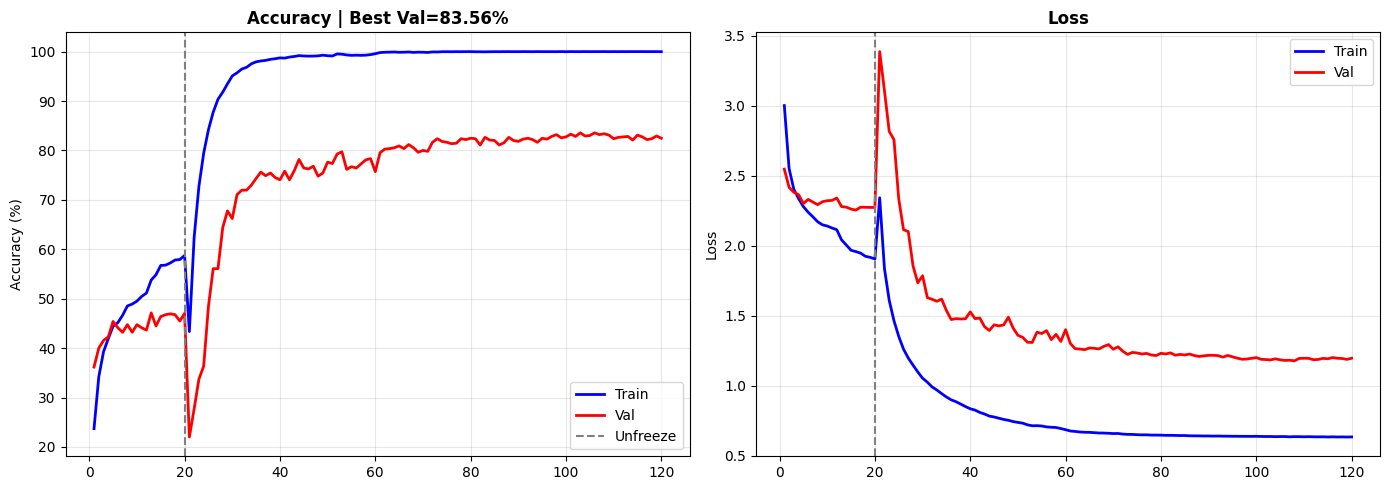

Evaluating on test set...
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 300ms/step

  Accuracy  : 83.56%
  F1 (macro): 0.8387
  Precision : 0.8394
  Recall    : 0.8402
  Paper ref : 95.98% (CIR-Net)

Per-class accuracy:
  Chr  1:  93.6%  ██████████████████
  Chr  2:  83.0%  ████████████████
  Chr  3:  89.6%  █████████████████
  Chr  4:  85.4%  █████████████████
  Chr  5:  79.2%  ███████████████
  Chr  6:  87.2%  █████████████████
  Chr  7:  87.5%  █████████████████
  Chr  8:  70.8%  ██████████████
  Chr  9:  74.5%  ██████████████
  Chr 10:  83.3%  ████████████████
  Chr 11:  85.4%  █████████████████
  Chr 12:  80.9%  ████████████████
  Chr 13:  89.6%  █████████████████
  Chr 14:  74.5%  ██████████████
  Chr 15:  72.9%  ██████████████
  Chr 16:  89.4%  █████████████████
  Chr 17:  83.3%  ████████████████
  Chr 18:  81.2%  ████████████████
  Chr 19:  87.5%  █████████████████
  Chr 20:  91.7%  ██████████████████
  Chr 21:  95.7%  ███████████████████
  Chr 22:  79.2%  ███████████████
  Chr  X:  71.1%  ██

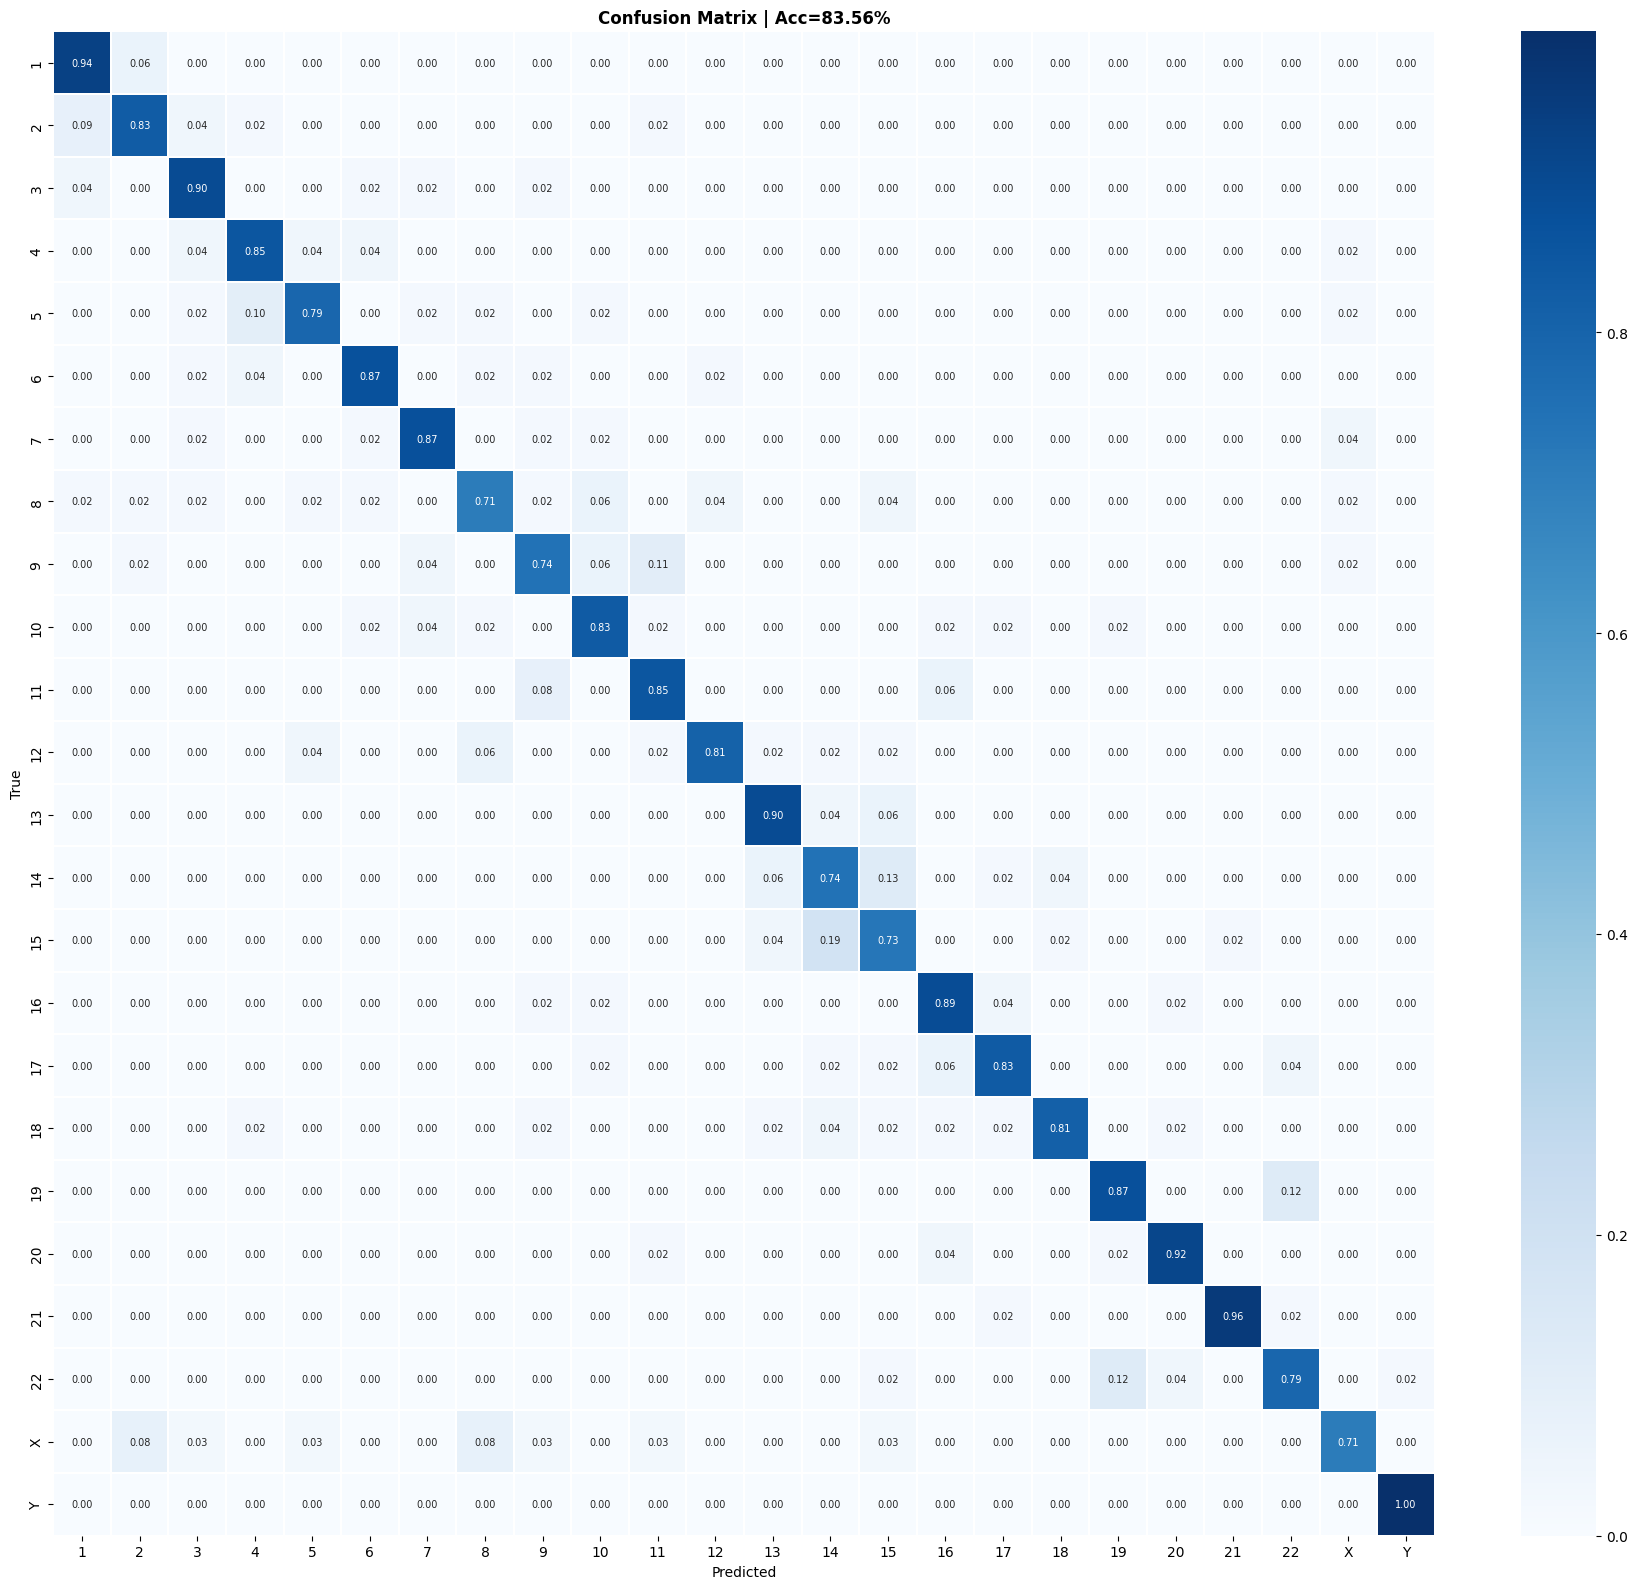

✅ Saved probs and labels


In [13]:
# Cell 8 — Training curves + test evaluation
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

# Curves
acc      = h1.history['accuracy']     + h2.history['accuracy']
val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
loss     = h1.history['loss']         + h2.history['loss']
val_loss = h1.history['val_loss']     + h2.history['val_loss']
p1_end   = len(h1.history['accuracy'])
ep       = range(1, len(acc)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
ax1.plot(ep, [a*100 for a in acc],    'b-', linewidth=2, label='Train')
ax1.plot(ep, [a*100 for a in val_acc],'r-', linewidth=2, label='Val')
ax1.axvline(p1_end, color='gray', linestyle='--', label='Unfreeze')
ax1.set_title(f'Accuracy | Best Val={max(val_acc)*100:.2f}%',
              fontweight='bold')
ax1.set_ylabel('Accuracy (%)'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(ep, loss,    'b-', linewidth=2, label='Train')
ax2.plot(ep, val_loss,'r-', linewidth=2, label='Val')
ax2.axvline(p1_end, color='gray', linestyle='--')
ax2.set_title('Loss', fontweight='bold')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/mobilenetv2_curves.png', dpi=150)
plt.show()

# Test evaluation
print('Evaluating on test set...')
probs = model.predict(test_ds, verbose=1)
preds = np.argmax(probs, axis=1)
true  = np.array(lbl_test)

acc_t = accuracy_score(true, preds) * 100
f1    = f1_score(true, preds, average='macro', zero_division=0)
prec  = precision_score(true, preds, average='macro', zero_division=0)
rec   = recall_score(true, preds, average='macro', zero_division=0)

print('\n' + '='*55)
print(f'  Accuracy  : {acc_t:.2f}%')
print(f'  F1 (macro): {f1:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  Paper ref : 95.98% (CIR-Net)')
print('='*55)

# Per-class accuracy
print('\nPer-class accuracy:')
for i in range(NUM_CLASSES):
    mask     = true == i
    cls_acc  = (preds[mask] == i).sum() / mask.sum() * 100 if mask.sum() > 0 else 0
    bar      = '█' * int(cls_acc / 5)
    flag     = ' ← LOW' if cls_acc < 70 else ''
    print(f'  Chr {CLASS_NAMES[i]:>2}: {cls_acc:5.1f}%  {bar}{flag}')

# Confusion matrix
cm   = confusion_matrix(true, preds)
cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
fig, ax = plt.subplots(figsize=(18,16))
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.3, ax=ax, annot_kws={'size':7})
ax.set_title(f'Confusion Matrix | Acc={acc_t:.2f}%', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/mobilenetv2_confusion.png', dpi=150)
plt.show()

# Save for ensemble later
np.save(f'{OUTPUT_DIR}/mobilenetv2_test_probs.npy', probs)
np.save(f'{OUTPUT_DIR}/lbl_test.npy', true)
print('✅ Saved probs and labels')

Cell 9

In [20]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    level = root.replace('/content/drive/MyDrive', '').count(os.sep)
    if level < 4:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        for f in list(files)[:3]:
            print(f'{indent}  {f}')

MyDrive/
  chromosome_models/
    mobilenetv2_bioimlab_weights.weights.h5
    mobilenetv2_bioimlab_final.keras
    mobilenetv2_history.json


In [24]:
# Cell 9 — Clean inference report on full karyograms
import os, cv2, xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from collections import Counter

# ── CORRECT PATHS — matches Cell 0A download locations ───────────────────────
OLD_IMG_DIR = '/content/chromo_data/Data/single_chromosomes_object/JEPG'
ANN_DIR     = '/content/chromo_data/Data/single_chromosomes_object/anntations'
NORM_CSV    = '/content/chromo_data/Data/normal.csv'
NABN_CSV    = '/content/chromo_data/Data/number_abnormalities.csv'
SABN_CSV    = '/content/chromo_data/Data/structural_abnormalities.csv'

os.makedirs('/content/outputs', exist_ok=True)

# ── Load abnormality CSVs ─────────────────────────────────────────────────────
norm_df = pd.read_csv(NORM_CSV, header=0)
nabn_df = pd.read_csv(NABN_CSV, header=0)
sabn_df = pd.read_csv(SABN_CSV, header=0)

norm_files = set(norm_df.iloc[1:, 0].astype(str).str.strip())
nabn_files = set(nabn_df.iloc[1:, 0].astype(str).str.strip())
sabn_files = set(sabn_df.iloc[1:, 0].astype(str).str.strip())

sabn_details = {}
for _, row in sabn_df.iloc[1:].iterrows():
    sabn_details[str(row.iloc[0]).strip()] = str(row.iloc[2]).strip()

nabn_details = {}
for _, row in nabn_df.iloc[1:].iterrows():
    nabn_details[str(row.iloc[0]).strip()] = str(row.iloc[2]).strip()

print(f'Normal patients    : {len(norm_files)}')
print(f'Numerical abn      : {len(nabn_files)}')
print(f'Structural abn     : {len(sabn_files)}')


# ── Crop + preprocess for inference (must match training pipeline) ────────────
def preprocess_crop_for_inference(crop_gray):
    """
    crop_gray : numpy array (H, W) grayscale uint8
    Returns   : numpy array (IMG_SIZE, IMG_SIZE, 3) float32 in [-1, 1]
    This MUST match what preprocess_tf does during training.
    """
    crop = cv2.resize(crop_gray, (IMG_SIZE, IMG_SIZE))          # resize
    crop = crop.astype(np.float32) / 255.0                      # [0,1]
    crop = np.stack([crop, crop, crop], axis=-1)                # (H,W,3)
    crop = (crop * 2.0) - 1.0                                   # [-1,1]
    return crop


def predict_karyogram_v2(img_path, ann_path, model):
    """
    Reads a full karyogram image, crops each chromosome via XML annotation,
    preprocesses each crop to (IMG_SIZE, IMG_SIZE, 3) float32,
    and returns predictions + confidences.
    """
    # Load as grayscale
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        # Try BMP explicit flag
        img_gray = cv2.imread(img_path, cv2.IMREAD_ANYDEPTH)
        if img_gray is None:
            print(f'  ⚠ Cannot read image: {img_path}')
            return None
        if len(img_gray.shape) == 3:
            img_gray = cv2.cvtColor(img_gray, cv2.COLOR_BGR2GRAY)

    H, W = img_gray.shape

    # Parse XML bounding boxes
    try:
        tree = ET.parse(ann_path)
        root = tree.getroot()
    except Exception as e:
        print(f'  ⚠ Cannot parse XML {ann_path}: {e}')
        return None

    boxes = []
    for obj in root.findall('object'):
        try:
            xmin = int(float(obj.findtext('bndbox/xmin')))
            ymin = int(float(obj.findtext('bndbox/ymin')))
            xmax = int(float(obj.findtext('bndbox/xmax')))
            ymax = int(float(obj.findtext('bndbox/ymax')))
            boxes.append((xmin, ymin, xmax, ymax))
        except Exception:
            continue

    if len(boxes) == 0:
        print(f'  ⚠ No bounding boxes in {ann_path}')
        return None

    # Crop each chromosome and preprocess
    crops = []
    for xmin, ymin, xmax, ymax in boxes:
        x1 = max(0, xmin - 4);  y1 = max(0, ymin - 4)
        x2 = min(W, xmax + 4);  y2 = min(H, ymax + 4)
        crop = img_gray[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        crops.append(preprocess_crop_for_inference(crop))

    if len(crops) == 0:
        return None

    # Batch predict — shape (N, IMG_SIZE, IMG_SIZE, 3)
    crops_arr = np.array(crops, dtype=np.float32)
    probs     = model.predict(crops_arr, verbose=0, batch_size=32)
    preds     = np.argmax(probs, axis=1)
    confs     = np.max(probs, axis=1)

    return preds, confs, len(boxes)


# ── Generate clean single-table report per patient ────────────────────────────
def generate_karyotype_report(img_path, ann_path, model, save_chart=False):
    fname  = os.path.basename(img_path)
    result = predict_karyogram_v2(img_path, ann_path, model)
    if result is None:
        return None

    preds, confs, total_boxes = result

    # Ground truth abnormality from CSV
    img_abn_type = None
    abn_chrs     = 'None'
    if fname in nabn_files:
        img_abn_type = 'Numerical'
        abn_chrs     = nabn_details.get(fname, 'not specified')
    elif fname in sabn_files:
        img_abn_type = 'Structural'
        abn_chrs     = sabn_details.get(fname, 'not specified')

    overall_status = '🔴 ABNORMAL' if img_abn_type else '🟢 NORMAL'
    class_counts   = Counter(preds)

    # Build one unified table (all 24 chromosomes in a single table)
    rows = []
    for i in range(NUM_CLASSES):
        count    = class_counts.get(i, 0)
        mask     = (preds == i)
        avg_conf = float(confs[mask].mean()) if mask.sum() > 0 else 0.0

        # Expected count per chromosome
        # Autosomes (1-22) : 2 copies
        # Chr X            : 2 copies (female) or 1 copy (male) → flag if 0 or >2
        # Chr Y            : 1 copy (male) or 0 (female) → flag if >1
        if i < 22:
            expected_count = 2
        elif i == 22:   # X
            expected_count = 2
        else:           # Y
            expected_count = 1

        # Abnormality flags
        count_flag  = (count > 0) and (count != expected_count)
        conf_flag   = (count > 0) and (avg_conf < CONF_THRESHOLD)
        chr_in_abn  = (abn_chrs != 'None') and (
                          CLASS_NAMES[i] in str(abn_chrs) or
                          str(i + 1)      in str(abn_chrs)
                      )

        is_abnormal = (img_abn_type and chr_in_abn) or count_flag or conf_flag

        if is_abnormal:
            status = '⚠️  Abnormal'
        elif count > 0:
            status = '✅ Normal'
        else:
            status = '—  Not detected'

        rows.append({
            'Chromosome' : f'Chr {CLASS_NAMES[i]}',
            'Expected'   : expected_count,
            'Detected'   : count,
            'Avg Conf'   : f'{avg_conf:.3f}' if count > 0 else '—',
            'Status'     : status,
        })

    df = pd.DataFrame(rows)

    # ── Print header ──────────────────────────────────────────────────────────
    print('\n' + '═' * 65)
    print(f'  KARYOTYPE ANALYSIS REPORT')
    print('═' * 65)
    print(f'  Patient Image  : {fname}')
    print(f'  Overall Status : {overall_status}')
    if img_abn_type:
        print(f'  Abnormality    : {img_abn_type}')
        print(f'  Affected Chr   : {abn_chrs}')
    else:
        print(f'  Abnormality    : None (normal karyotype)')
    print(f'  Bounding boxes : {total_boxes}  |  Classified: {len(preds)}')
    print('─' * 65)

    # ── Single clean table ────────────────────────────────────────────────────
    print(f'  {"Chromosome":<14} {"Expected":>9} {"Detected":>9} {"Avg Conf":>10}   Status')
    print('  ' + '─' * 60)
    for r in rows:
        print(f'  {r["Chromosome"]:<14} {r["Expected"]:>9} {r["Detected"]:>9} '
              f'{r["Avg Conf"]:>10}   {r["Status"]}')
    print('─' * 65)

    # ── Summary ───────────────────────────────────────────────────────────────
    normal_count = sum(1 for r in rows if '✅' in r['Status'])
    abn_count    = sum(1 for r in rows if '⚠️'  in r['Status'])
    nd_count     = sum(1 for r in rows if '—'  in r['Status'])
    print(f'  ✅ Normal classes    : {normal_count}')
    print(f'  ⚠️  Abnormal classes : {abn_count}')
    print(f'  —  Not detected     : {nd_count}')
    print('═' * 65 + '\n')

    # ── Bar chart: expected vs detected ──────────────────────────────────────
    if save_chart:
        fig, ax = plt.subplots(figsize=(16, 5))
        x        = np.arange(NUM_CLASSES)
        detected = df['Detected'].astype(int).values
        expected = df['Expected'].astype(int).values

        ax.bar(x - 0.2, expected, 0.38, label='Expected',
               color='steelblue', alpha=0.8)
        ax.bar(x + 0.2, detected, 0.38, label='Detected',
               color='tomato',    alpha=0.8)

        # Highlight abnormal bars
        for i, r in enumerate(rows):
            if '⚠️' in r['Status']:
                ax.bar(i + 0.2, detected[i], 0.38,
                       color='red', alpha=0.9)

        ax.set_xticks(x)
        ax.set_xticklabels([f'Chr {n}' for n in CLASS_NAMES],
                           rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Count')
        ax.set_title(
            f'Expected vs Detected per Chromosome  |  {fname}  |  {overall_status}',
            fontweight='bold'
        )
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        chart_path = f'/content/outputs/karyotype_{os.path.splitext(fname)[0]}.png'
        plt.savefig(chart_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'✅ Chart saved → {chart_path}\n')

    return df


# ── Run on 1 normal + 1 abnormal patient ─────────────────────────────────────
print('Running karyotype analysis...\n')

ann_files      = sorted([f for f in os.listdir(ANN_DIR) if f.endswith('.xml')])
shown_normal   = False
shown_abnormal = False
all_reports    = []

for xf in ann_files:
    if shown_normal and shown_abnormal:
        break

    stem     = os.path.splitext(xf)[0]
    ann_path = os.path.join(ANN_DIR, xf)
    fname    = stem + '.jpg'

    # Try jpg / bmp extensions
    img_path = os.path.join(IMG_DIR, fname)
    if not os.path.exists(img_path):
        img_path = os.path.join(IMG_DIR, stem + '.bmp')
    if not os.path.exists(img_path):
        continue

    is_abn = (fname in nabn_files) or (fname in sabn_files)

    if is_abn and not shown_abnormal:
        df = generate_karyotype_report(img_path, ann_path, model, save_chart=True)
        if df is not None:
            all_reports.append(df)
        shown_abnormal = True

    elif not is_abn and not shown_normal:
        df = generate_karyotype_report(img_path, ann_path, model, save_chart=True)
        if df is not None:
            all_reports.append(df)
        shown_normal = True

if not shown_abnormal:
    print('⚠ No abnormal patient found in annotation folder.')
if not shown_normal:
    print('⚠ No normal patient found in annotation folder.')

Normal patients    : 4892
Numerical abn      : 58
Structural abn     : 49
Running karyotype analysis...

⚠ No abnormal patient found in annotation folder.
⚠ No normal patient found in annotation folder.


Structured Tabular output:

Running predictions...

  TABLE 1: PER-CLASS CLASSIFICATION RESULTS
 Class Chromosome  True Count  Predicted Count  Normal  Abnormal  Avg Conf %  Precision  Recall  F1 Score  Status
     1      Chr 1          47               51      45         6   84.800003      0.863   0.936     0.898  ✅ Good
     2      Chr 2          47               47      37        10   79.400002      0.830   0.830     0.830  ✅ Good
     3      Chr 3          48               52      42        10   81.599998      0.827   0.896     0.860  ✅ Good
     4      Chr 4          48               50      40        10   82.300003      0.820   0.854     0.837  ✅ Good
     5      Chr 5          48               44      37         7   82.199997      0.864   0.792     0.826  ✅ Good
     6      Chr 6          47               47      41         6   82.900002      0.872   0.872     0.872  ✅ Good
     7      Chr 7          48               48      38        10   81.599998      0.875   0.875     0.875  ✅ Good
     8      Chr 8   

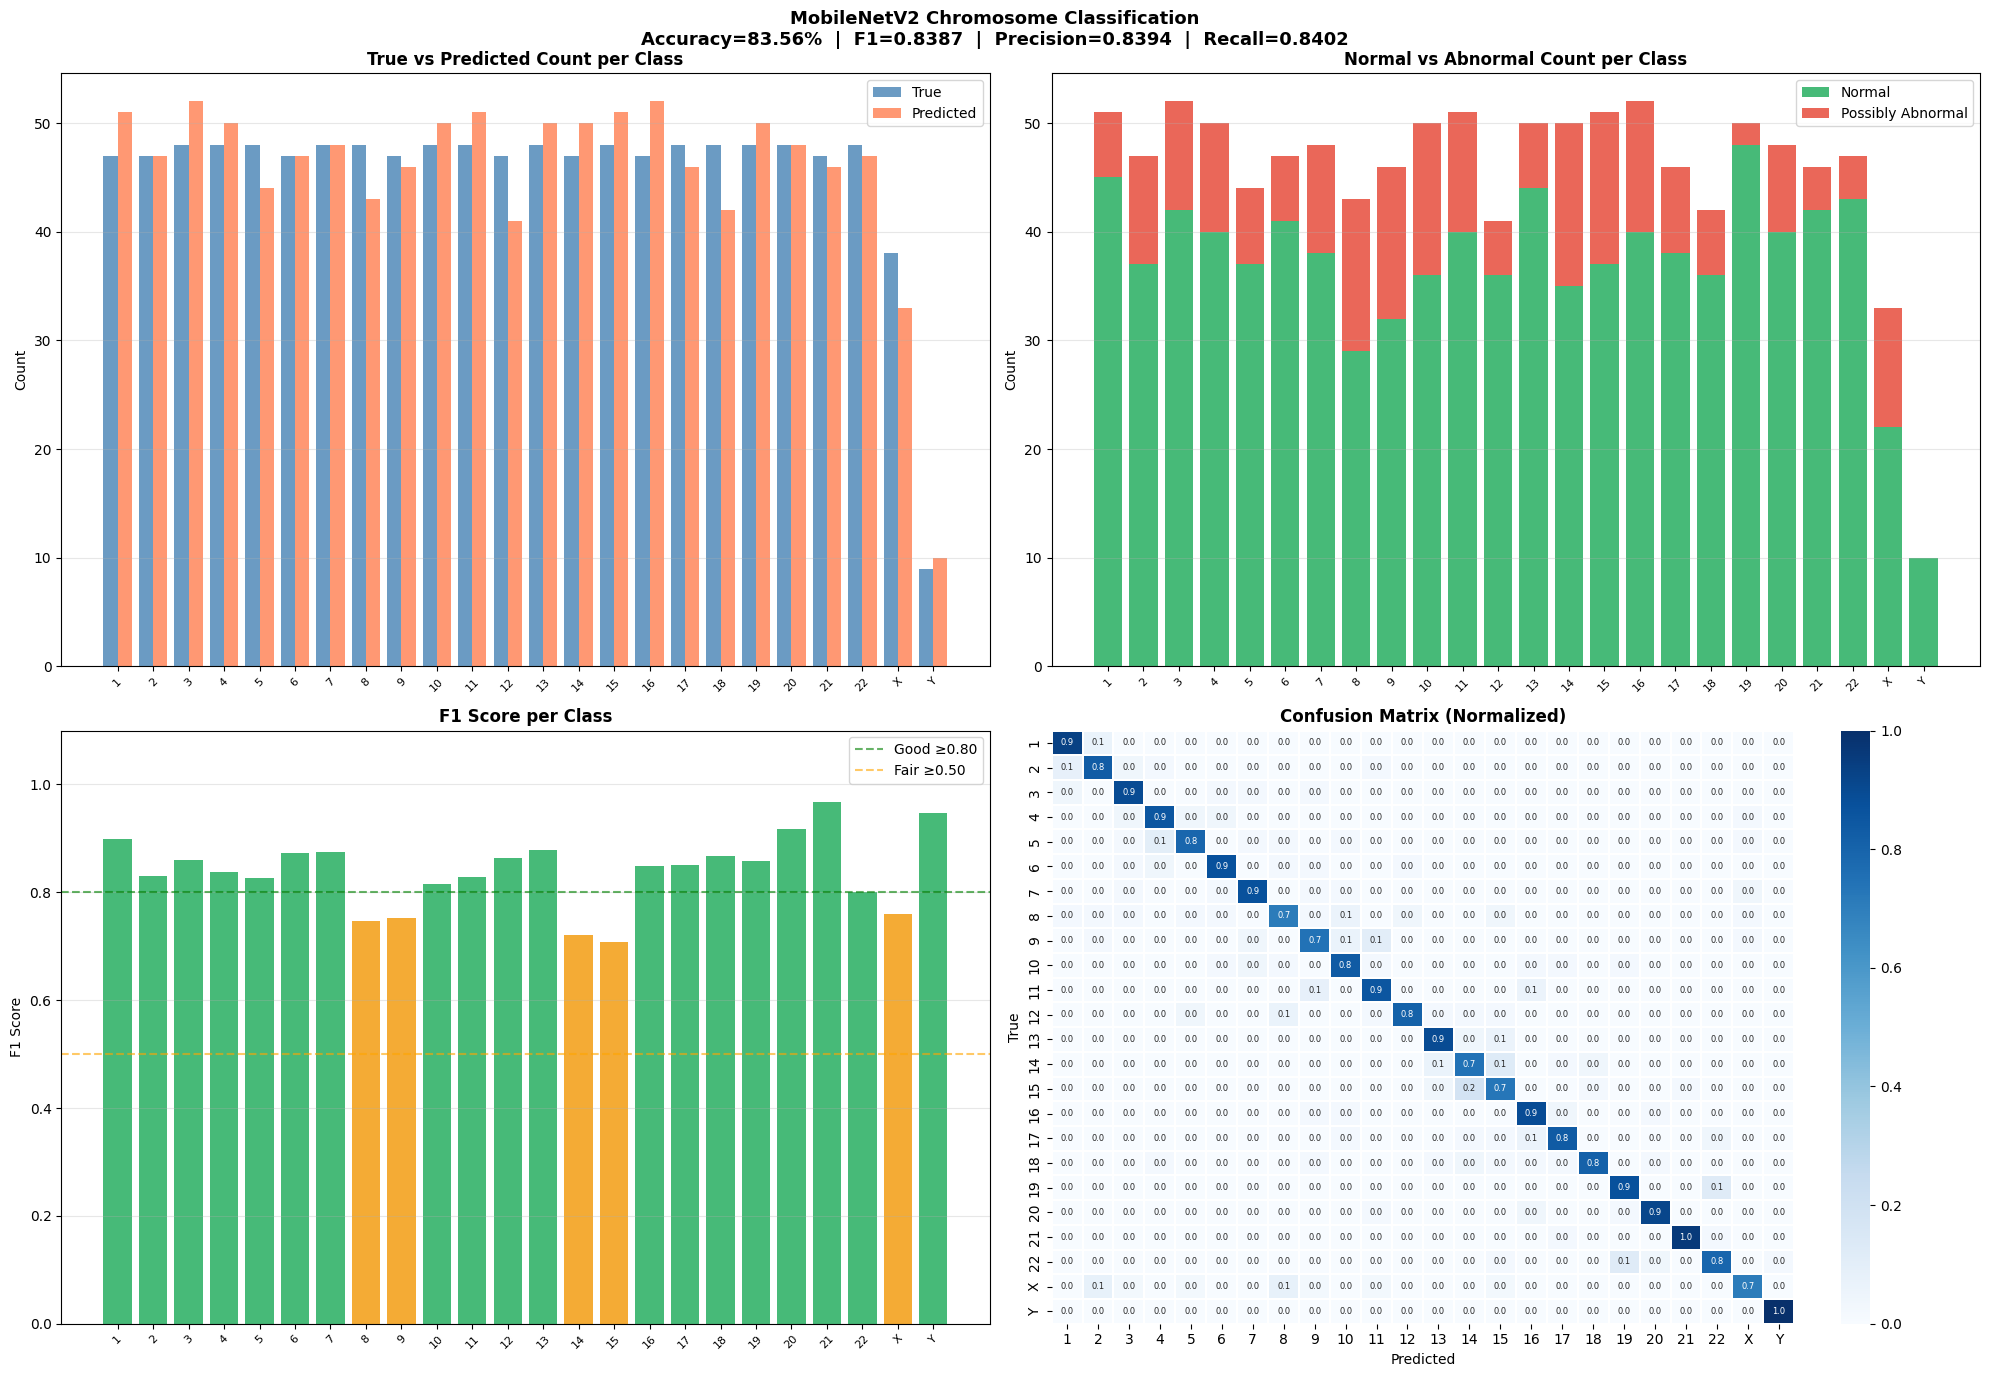

✅ Saved: /content/outputs/full_results_chart.png
Drive save skipped (Mountpoint must not already contain files) — files at /content/outputs/


In [25]:
# Cell 10 — Structured Results Table + Karyotype Report
# Config values (re-declare here in case of fresh session)
CONF_THRESHOLD = 0.70
NUM_CLASSES    = 24
CLASS_NAMES    = [str(i) for i in range(1, 23)] + ['X', 'Y']
IMG_SIZE       = 128

import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score,
                              confusion_matrix)
from collections import Counter

os.makedirs('/content/outputs', exist_ok=True)

# ── Get predictions ───────────────────────────────────────────────────────────
print('Running predictions...')
probs_all = model.predict(test_ds, verbose=0)
preds_all = np.argmax(probs_all, axis=1)
confs_all = np.max(probs_all, axis=1)
# Load saved test labels (saved by the model-save cell)
SAVE_DIR = '/content/drive/MyDrive/chromosome_models'
true_all = np.load(f'{SAVE_DIR}/lbl_test.npy')

# ── Overall metrics ───────────────────────────────────────────────────────────
acc  = accuracy_score(true_all, preds_all) * 100
f1   = f1_score(true_all, preds_all, average='macro', zero_division=0)
prec = precision_score(true_all, preds_all, average='macro', zero_division=0)
rec  = recall_score(true_all, preds_all, average='macro', zero_division=0)

# ── Per-class metrics ─────────────────────────────────────────────────────────
per_f1   = f1_score(true_all, preds_all, average=None, zero_division=0)
per_prec = precision_score(true_all, preds_all, average=None, zero_division=0)
per_rec  = recall_score(true_all, preds_all, average=None, zero_division=0)

pred_counts = Counter(preds_all.tolist())
true_counts = Counter(true_all.tolist())

norm_by_cls = Counter()
abn_by_cls  = Counter()
for cls, conf in zip(preds_all, confs_all):
    if conf < CONF_THRESHOLD:
        abn_by_cls[int(cls)] += 1
    else:
        norm_by_cls[int(cls)] += 1

avg_conf_by_cls = {}
for i in range(NUM_CLASSES):
    c = [conf for pred, conf in zip(preds_all, confs_all) if pred == i]
    avg_conf_by_cls[i] = np.mean(c) * 100 if c else 0.0

# ── TABLE 1: Per-class classification results ─────────────────────────────────
rows = []
for i in range(NUM_CLASSES):
    rows.append({
        'Class'          : i + 1,
        'Chromosome'     : f'Chr {CLASS_NAMES[i]}',
        'True Count'     : true_counts.get(i, 0),
        'Predicted Count': pred_counts.get(i, 0),
        'Normal'         : norm_by_cls.get(i, 0),
        'Abnormal'       : abn_by_cls.get(i, 0),
        'Avg Conf %'     : round(avg_conf_by_cls[i], 1),
        'Precision'      : round(per_prec[i], 3),
        'Recall'         : round(per_rec[i], 3),
        'F1 Score'       : round(per_f1[i], 3),
        'Status'         : '✅ Good' if per_f1[i] >= 0.80
                           else ('⚠️ Fair' if per_f1[i] >= 0.50
                           else '❌ Poor'),
    })

df = pd.DataFrame(rows)

print('\n' + '='*105)
print('  TABLE 1: PER-CLASS CLASSIFICATION RESULTS')
print('='*105)
print(df.to_string(index=False))
print('='*105)
print(f'\n  Overall Accuracy : {acc:.2f}%')
print(f'  Macro F1         : {f1:.4f}')
print(f'  Macro Precision  : {prec:.4f}')
print(f'  Macro Recall     : {rec:.4f}')
print(f'  Paper benchmark  : 95.98% (CIR-Net full data)')

df.to_csv('/content/outputs/per_class_results.csv', index=False)
print('\n✅ Saved: /content/outputs/per_class_results.csv')

# ── TABLE 2: Karyotype report ─────────────────────────────────────────────────
expected = {i: 2 for i in range(22)}
expected[22] = 2   # X (female) or 1 (male)
expected[23] = 0   # Y (female) or 1 (male)

print('\n' + '='*90)
print('  TABLE 2: KARYOTYPE ANALYSIS REPORT')
print('='*90)
print(f'  {"Chr":<8} {"Predicted":>10} {"Expected":>10} {"Normal":>8} '
      f'{"Abnormal":>10} {"Avg Conf":>10}  {"Verdict"}')
print('  ' + '-'*85)

flagged_num = []
flagged_str = []
summary_rows = []

for i in range(NUM_CLASSES):
    found    = pred_counts.get(i, 0)
    exp      = expected.get(i, 2)
    n_norm   = norm_by_cls.get(i, 0)
    n_abn    = abn_by_cls.get(i, 0)
    avg_c    = avg_conf_by_cls[i]
    num_flag = found != exp

    if num_flag:
        verdict = f'⚠️ Numerical (found {found} expected {exp})'
        flagged_num.append(CLASS_NAMES[i])
    elif n_abn > 0:
        verdict = f'⚠️ Structural ({n_abn} abnormal)'
        flagged_str.append(CLASS_NAMES[i])
    elif found == 0:
        verdict = '— Not detected'
    else:
        verdict = '✅ Normal'

    print(f'  Chr {CLASS_NAMES[i]:>2}    {found:>10}  {exp:>10}  '
          f'{n_norm:>8}  {n_abn:>10}  {avg_c:>8.1f}%  {verdict}')

    summary_rows.append({
        'Chromosome': f'Chr {CLASS_NAMES[i]}',
        'Predicted': found,
        'Expected': exp,
        'Normal': n_norm,
        'Abnormal': n_abn,
        'Avg Confidence %': round(avg_c, 1),
        'Verdict': verdict
    })

print('='*90)
n_normal_cls = NUM_CLASSES - len(flagged_num) - len(flagged_str)
print(f'  ✅ Normal classes     : {n_normal_cls}')
print(f'  ⚠️  Numerical abn.    : {len(flagged_num)}'
      + (f' → Chr {", ".join(flagged_num)}' if flagged_num else ''))
print(f'  ⚠️  Structural abn.   : {len(flagged_str)}'
      + (f' → Chr {", ".join(flagged_str)}' if flagged_str else ''))
print('='*90)

df_kary = pd.DataFrame(summary_rows)
df_kary.to_csv('/content/outputs/karyotype_report.csv', index=False)
print('✅ Saved: /content/outputs/karyotype_report.csv')

# ── CHART 1: Predicted vs True counts ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

x = np.arange(NUM_CLASSES)
w = 0.4
ax = axes[0][0]
ax.bar(x - w/2, [true_counts.get(i,0) for i in range(NUM_CLASSES)],
       w, label='True', color='steelblue', alpha=0.8)
ax.bar(x + w/2, [pred_counts.get(i,0) for i in range(NUM_CLASSES)],
       w, label='Predicted', color='coral', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=45, fontsize=8)
ax.set_title('True vs Predicted Count per Class', fontweight='bold')
ax.set_ylabel('Count'); ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── CHART 2: Normal vs Abnormal per class ─────────────────────────────────────
ax = axes[0][1]
norm_vals = [norm_by_cls.get(i,0) for i in range(NUM_CLASSES)]
abn_vals  = [abn_by_cls.get(i,0)  for i in range(NUM_CLASSES)]
ax.bar(CLASS_NAMES, norm_vals, label='Normal', color='#27AE60', alpha=0.85)
ax.bar(CLASS_NAMES, abn_vals, bottom=norm_vals,
       label='Possibly Abnormal', color='#E74C3C', alpha=0.85)
ax.set_xticklabels(CLASS_NAMES, rotation=45, fontsize=8)
ax.set_title('Normal vs Abnormal Count per Class', fontweight='bold')
ax.set_ylabel('Count'); ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── CHART 3: F1 per class ─────────────────────────────────────────────────────
ax = axes[1][0]
colors = ['#27AE60' if f >= 0.80 else '#F39C12' if f >= 0.50
          else '#E74C3C' for f in per_f1]
ax.bar(CLASS_NAMES, per_f1, color=colors, alpha=0.85)
ax.axhline(0.80, color='green', linestyle='--', alpha=0.6, label='Good ≥0.80')
ax.axhline(0.50, color='orange', linestyle='--', alpha=0.6, label='Fair ≥0.50')
ax.set_xticklabels(CLASS_NAMES, rotation=45, fontsize=8)
ax.set_title('F1 Score per Class', fontweight='bold')
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.1)
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── CHART 4: Confusion matrix ─────────────────────────────────────────────────
ax = axes[1][1]
cm   = confusion_matrix(true_all, preds_all)
cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
sns.heatmap(cm_n, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.2, ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 6})
ax.set_title('Confusion Matrix (Normalized)', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.suptitle(
    f'MobileNetV2 Chromosome Classification\n'
    f'Accuracy={acc:.2f}%  |  F1={f1:.4f}  |  '
    f'Precision={prec:.4f}  |  Recall={rec:.4f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('/content/outputs/full_results_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: /content/outputs/full_results_chart.png')

# ── Save to Drive ─────────────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    drive_out = '/content/drive/MyDrive/CIRNet_Output'
    os.makedirs(drive_out, exist_ok=True)
    import shutil
    for f in os.listdir('/content/outputs'):
        shutil.copy(f'/content/outputs/{f}', f'{drive_out}/{f}')
    print(f'✅ All outputs saved to Drive: {drive_out}')
except Exception as e:
    print(f'Drive save skipped ({e}) — files at /content/outputs/')